# R-KV Token Dropping — Route A, exact and linear, on the GPU
---

Long prompts create large KV caches. They eat GPU memory, limit how many requests
fit in a batch, and a smaller batch means lower decode throughput. *Token
dropping* shrinks each request's KV cache — by half in this notebook — so more
requests fit and decoding runs faster.

This notebook uses the LMCache SDK to pull a request's KV cache out after
prefill, compress it, and put it back before decode. The compression algorithm
is **R-KV**: it ranks past tokens by **attention importance**, like SnapKV, and
subtracts a second term, **redundancy** — how similar a token's key is to the
*other* keys:

$$\text{score}(j) \;=\; \lambda \cdot \underbrace{\text{importance}(j)}_{\text{attended to?}} \;-\; (1-\lambda) \cdot \underbrace{\text{redundancy}(j)}_{\text{says something new?}}$$

Keeping tokens that are both attended-to **and** non-redundant works especially
well on the repetitive output of reasoning models. The catch is that the
redundancy term compares **all pairs of keys**: $O(n^2 d)$ per layer, against
$O(w n d)$ for SnapKV's importance term. At $n = 16128$ with window $w = 64$
that is ~250x more arithmetic per layer, and a literal implementation also
materializes an $n \times n$ matrix per layer.

## This notebook

It implements the same exact linear rewrite as
[`cpu_exact`](./rkv_variant_cpu_exact.ipynb), moved to the **GPU** and tiled over rows so
the memory footprint becomes a knob instead of a function of prompt length. It
is the **default choice**: simultaneously the fastest and the smallest of the
four, exact, in ~1.55 GiB of VRAM.

It is one of four independent notebooks that keep the same 50% of the tokens and
therefore deliver the **same decode speed-up** — 1766–1785 tok/s, a 1.1% spread, even
though they compress with completely different code. What separates them is the **cost of
compressing**:

| | [one-shot](../rkv_token_dropping.ipynb) | [cpu_exact](./rkv_variant_cpu_exact.ipynb) | [gpu_exact](./rkv_variant_gpu_exact.ipynb) | [buffered_cpu](./rkv_variant_buffered_cpu.ipynb) |
|---|---|---|---|---|
| Formulation | route A, literal | route A, linear | route A, linear | route B, chunked |
| Exact? | yes (the reference) | yes, rel. err ~2e-6 | yes, rel. err ~5e-7 | **no**, ~96% agreement |
| Redundancy cost | $O(n^2 d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ |
| VRAM | ~9.8 GiB | none | **1.55 GiB** | none |
| Compress 30 requests | 41.6 s | 67.3 s | **37.5 s** | **29.9 s** |
| Decode throughput | 1766 tok/s | 1785 tok/s | 1774 tok/s | 1774 tok/s |
| Accuracy (baseline 10–11/30) | 16/30 | 15/30 | 16/30 | 14/30 |


Start with the [one-shot notebook](../rkv_token_dropping.ipynb): it is R-KV
written the way the paper describes it, and it is the reference the exact
variants here are checked against.

Numbers above were measured on 30 LongBench-v2 prompts (~16k tokens each) with
Qwen3-8B on one H200 and a 96-core Xeon. They are hardware- and
workload-dependent; treat them as reference measurements, not guarantees.

## Requirements

* A small ~10-line modification to vLLM exposes intermediate tensors to LMCache.
  See [README.md](../README.md).
* A GPU is required for serving. To see token dropping increase the decode batch
  size, tune the GPU memory utilization together with the number of requests.
* Data moves between the LMCache server and the SDK through shared memory; if it
  is unavailable the SDK falls back to pickle.
* Run this notebook from its own directory; it imports `../utils.py`.


## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

**1. Start LMCache server first**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`

```sh
lmcache server \
    --l1-size-gb 400 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_sdk \
    --no-l1-use-lazy \
    --enable transfer_query
```

**2. Wait until LMCache server is ready**

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

**3. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
LMCACHE_TRANSFER_INTERMEDIATE_TENSORS=true \
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

**4. Wait until vLLM is ready**

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

In [1]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
import math
import matplotlib.pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once

sys.path.append("..")  # utils.py lives next to the main notebook

from utils import (  # noqa: E402
    rerotate_k_cache,
    make_post_completion,
    score_answers,
)

print_banner_once(sys.stdout)
logger = init_logger(__name__)

[2026-08-12 00:09:03,132] LMCache INFO: torch_dev=<module 'torch.cuda' from '/home/sigma/github/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (_device_detect.py:143:lmcache.v1.platform._device_detect)


[2026-08-12 00:09:03,211] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.5.4.dev21 (g0c487832)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [2]:
model_name = "/data/models/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 5120
temperature = 0.0  # greedy decode so generated answers are deterministic and scorable
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

# Streams prefilled per submission. LMCache's query ring buffer maps a forward
# step's query rows to ring slots positionally (qringbuffer.py
# build_q_step_state), assuming each request contributed exactly its store op's
# token count of rows. Continuous batching breaks that, so the captured queries
# are silently wrong or short. Measured query-row reproducibility across two
# identical runs: 100.0% at 1 stream, 99.7% at 4, 9.8% at 30. R-KV's importance
# term is entirely query-driven, so prefill is submitted one stream at a time.
prefill_group_size = 1

## Configuring the model and LMCache endpoint

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-08-12 00:09:03,665] LMCache INFO: Initialized LMCacheSDKContext with instance_id=3264019442450718575, model_name=/data/models/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_sdk, kind=LMCacheSDKCacheKind.KV (context.py:122:lmcache.sdk.context)


[2026-08-12 00:09:03,667] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:879:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-12 00:09:03,855] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-12 00:09:03,861] LMCache INFO: Engine KV Format: 7 NL x [NB, 2, NH, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)


[2026-08-12 00:09:03,863] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=268435456000) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)


...

[2026-08-12 00:09:22,571] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-12 00:09:22,571] LMCache INFO: Engine KV Format: 3 NL x [NB, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)


[2026-08-12 00:09:22,573] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=268435456000) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)


[2026-08-12 00:09:41,105] LMCache INFO: SHM pinned=True for shm_name=lmcache_l1_pool_lmcache_sdk (shm.py:118:lmcache.v1.multiprocess.transfer_context.shm)


[2026-08-12 00:09:41,106] LMCache INFO: Worker non-GPU transfer context registered (instance_id=472683994697095587, mode=SHM) (worker_transfer.py:745:lmcache.v1.multiprocess.transfer_context.worker_transfer)


## Constructing Prompt

In [4]:
prompts = []
answers = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)
    answers.append(ds[i]["answer"])

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Using the latest cached version of the dataset since raniayu/token-dropping-demo couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'default' at /home/sigma/.cache/huggingface/datasets/raniayu___token-dropping-demo/default/0.0.0/0581768ecd24dea91b4af0dea6c30e526282e929 (last modified on Fri Jul 24 22:25:51 2026).


Loaded 30 prompts from the dataset.
Total prompts length: 423428 tokens.
Mean prompt length: 14114.27 tokens.
Max prompt length: 16807 tokens.
Min prompt length: 10159 tokens.


## Baseline (without token dropping)


In [5]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.request_stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
before_drop_data = results.to_dict()
before_texts = [stream.output_text for stream in batch.request_streams.values()]

[2026-08-12 00:09:44,763] LMCache INFO: prefill: 2.80 s in groups of 1 (420791162.py:24:__main__)


======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       153.28
Total Output Tokens:                                                      153451
Decode Throughput (tokens/s):                                            1001.13


## Clear LMCache


In [6]:
!curl -X POST {lmcache_url}/cache/clear


{"status":"ok","cleared":{"tier":"l1"}}

## With R-KV Token Dropping — Route A, exact and linear, on the GPU

In [7]:
# Standard
import contextlib
import threading

# --- R-KV hyperparameters ----------------------------------------------------
# Scores are averaged over KV heads and summed over layers, so a request keeps
# ONE token subset. LMCache re-injects a single contiguous KV with a single
# kept-token list, so per-head eviction is not expressible here.
rkv_window_size = 16  # observation window: the last w queries vote on importance
rkv_drop_ratio = 0.5  # fraction of tokens to evict
rkv_kernel_size = 7  # max-pool width applied to the importance scores
rkv_mix_lambda = 0.25  # score = lambda * importance - (1 - lambda) * redundancy
rkv_sim_threshold = 0.5  # cosine above this counts as "similar"


# --- Tensor plumbing ---------------------------------------------------------
def model_heads():
    """(num_q_heads, num_kv_heads, head_dim) for the served model."""
    q = config.num_attention_heads
    kv = getattr(config, "num_key_value_heads", q)
    return q, kv, getattr(config, "head_dim", config.hidden_size // q)


def to_heads(flat, rows, heads, head_dim, device=None):
    """[rows, heads * head_dim] -> [1, heads, rows, head_dim] in fp32."""
    t = (
        flat.to(dtype=torch.float32)
        if device is None
        else flat.to(device, torch.float32)
    )
    return t.reshape(rows, heads, head_dim).permute(1, 0, 2).unsqueeze(0)


def q_by_layer(q_tensor):
    """Normalise the SDK's query tensor to [num_layers, T, q_heads * head_dim]."""
    if q_tensor.ndim == 4 and q_tensor.shape[0] == 1:
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"unexpected q_tensor shape {tuple(q_tensor.shape)}")


def attention_logits(query, key, pooling="max"):
    """q @ k^T / sqrt(d), pooled from query heads down to KV heads (GQA).

    query: [1, q_heads, q_len, d]   key: [1, kv_heads, kv_len, d]
    """
    _, q_heads, q_len, d = query.shape
    kv_heads = key.shape[1]
    group = q_heads // kv_heads
    if group == 1:
        return torch.matmul(query, key.transpose(2, 3)) / math.sqrt(d)
    q = query.view(1, kv_heads, group, q_len, d)
    attn = torch.matmul(q, key.unsqueeze(2).transpose(3, 4)) / math.sqrt(d)
    return attn.mean(dim=2) if pooling == "mean" else attn.max(dim=2).values


def importance(k, q_win, past_len):
    """How much the observation window attends to each past token.

    Only the window queries are passed in, so this is O(w * n * d) rather than
    the O(n^2 * d) the reference spends before discarding all but the last w rows.
    """
    attn = attention_logits(q_win, k)[:, :, :, :past_len]
    scores = F.softmax(attn, dim=-1, dtype=torch.float32).mean(dim=-2)
    return F.max_pool1d(
        scores, kernel_size=rkv_kernel_size, padding=rkv_kernel_size // 2, stride=1
    )


def redundancy_reference(key_states, threshold=rkv_sim_threshold):
    """Literal R-KV redundancy: materialises the whole n x n matrix.

    Only used as the correctness oracle in the self-tests -- never on a real
    prompt, where it would allocate kv_heads * n^2 floats per layer.
    """
    _, _, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    sim = torch.matmul(k, k.transpose(-1, -2))
    eye = torch.eye(n, dtype=torch.bool, device=k.device).view(1, 1, n, n)
    sim.masked_fill_(eye, 0.0)

    # Per row, exempt the LARGEST column index that is above threshold (or
    # column 0 if none qualifies) -- R-KV's `similarity_retain` rule.
    mask = sim > threshold
    idx = torch.arange(n, device=k.device).view(1, 1, 1, n)
    retain = torch.where(mask, idx, torch.zeros_like(mask, dtype=torch.long))
    sim.scatter_(-1, retain.max(dim=-1)[0].unsqueeze(-1), 0)
    return sim.mean(dim=-2).softmax(dim=-1)


def prepare(tensors, token_source):
    """Common bookkeeping shared by every drop_tokens_fn."""
    kv = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]  # [2, L, T, D]
    q = q_by_layer(tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY])
    seq_len = min(kv.shape[2], q.shape[1], len(token_source))
    past_len = seq_len - rkv_window_size
    if past_len <= 0:
        raise ValueError(f"seq_len {seq_len} must exceed window {rkv_window_size}")
    keep_total = int(round(seq_len * (1 - rkv_drop_ratio)))
    keep_past = max(0, min(keep_total - rkv_window_size, past_len))
    q_win = q[:, past_len:seq_len, :]  # window only: ~2.4 MiB, not ~4.8 GiB
    return kv, q_win, seq_len, past_len, keep_past


def select(scores, past_len, seq_len, keep_past):
    """Top-scoring past tokens plus the whole observation window."""
    top = torch.topk(scores, k=keep_past).indices.sort().values
    tail = torch.arange(past_len, seq_len, device=scores.device)
    return torch.cat([top, tail]).to(torch.long).cpu()


def rerotate(kv_tensor, keep_idx, device):
    """Gather the kept tokens and move their RoPE to the new positions."""
    gathered = kv_tensor[:, :, keep_idx, :].clone().to(device)
    out = rerotate_k_cache(
        gathered,
        old_positions=keep_idx.to(device),
        new_positions=torch.arange(keep_idx.numel(), device=device),
        model_config=config,
    )
    return out.cpu()

### Route A, exact and linear, on the GPU

> **Trades implementation complexity for everything else.** Nothing is
> sacrificed at run time — it is exact, the fastest, and the smallest. What it
> costs is the most intricate code of the four.
>
> | | |
> |---|---|
> | **Buys you** | Fastest exact option, **~6× less VRAM than the [one-shot notebook](../rkv_token_dropping.ipynb)**, linear in $n$ |
> | **Costs you** | The most implementation complexity: row tiling, a device-specific active-set choice, layer-tiled re-rotation, a carefully narrowed lock |
> | Exact? | Yes — relative error ~5e-7, identical kept-token set |
> | VRAM | **~1.55 GiB** at `cap = 2` (the default); 1.13 GiB at `cap = 1` |
> | Compress 30 requests | 37.5 s |
> | Decode throughput | 1774 tok/s |
> | Pick it when | Default choice — unless you have no VRAM to spare at all |

The same rewrite as [`cpu_exact`](./rkv_variant_cpu_exact.ipynb), moved to the GPU. This is the one to use:
it is **simultaneously the smallest and the fastest** of the four.

The reason both improve at once is that they are the same fact. The one-shot
notebook needs ~10 GiB because the $n \times n$ matrix *is* the memory; once it is gone,
what remains is a single similarity block whose size is a **knob** rather than a
function of prompt length.

## VRAM: how small, and why it is bounded

The only large tensor left is the scan block, so the footprint follows directly
from the tile sizes and nothing else:

$$\text{peak} \;\approx\; \text{kv\_heads} \times \text{row\_tile} \times \text{col\_block} \times 7 \text{ bytes}$$

(fp32 block plus the boolean and `uint8` compare temporaries). `n` does not
appear. Measured with 30 concurrent requests at $n = 16807$, $L = 36$:

| col_block | row_tile | cap | peak | wall | s/req |
|---|---|---|---|---|---|
| 2048 | 4096 | 1 | 1.54 GiB | 4.8 s | 0.16 |
| **1024** | **2048** | **1** | **1.23 GiB** | **4.8 s** | **0.16** |
| 1024 | 2048 | 2 | 1.49 GiB | 5.2 s | 0.17 |
| 1024 | 1024 | 4 | 1.79 GiB | 11.6 s | 0.39 |

End to end, with the RoPE re-rotation included, the measured peak was
**1.13 GiB** at `cap = 1` and **1.54–1.55 GiB** at `cap = 2` (the default,
reproduced across three full runs). Below ~1024 the kernel launch overhead starts
to dominate, which is why the tiles are not pushed further down.

Note that `cap = 1` is as fast as `cap = 2` or `4`: a **single request already
saturates the GPU**, so extra concurrency buys nothing but memory pressure.
That inverts the one-shot notebook, where the cap exists to survive at all — here it
exists to keep the footprint at its floor.

## What was optimized

| # | Change | Why it mattered |
|---|---|---|
| 1 | **Row tiling.** Score `row_tile` rows at a time instead of all $n$. | This is what makes the footprint a knob. The [CPU version](./rkv_variant_cpu_exact.ipynb) scores the whole first block at once: `[kv_heads, n, col_block]` is 1.1 GiB at $n = 16807$. |
| 2 | **Shared active set across heads — the opposite of the CPU choice.** | Deliberate. On the CPU, FLOPs are scarce, so per-head sets are essential. On the GPU, *kernel launches* are scarce: one shared set does ~7× the residual FLOPs ($0.98^8 \approx 0.85$, so ~15% of rows stay active rather than 2%) while issuing an eighth of the launches — and the residual is a rounding error on an H200 either way. Same algorithm, opposite tuning. |
| 3 | **Layer-tiled re-rotation.** Ship 4 layers to the device at a time. | Moving all `[2, 36, keep, 1024]` at once is 1.24 GiB — larger than the entire scoring peak — for no speed gain. |
| 4 | **Narrow the lock.** Only the device sections hold the semaphore. | The first version held it across the whole function and took **41.0 s** of compression although the benchmark put all 30 requests' GPU work at 4.8 s. The culprit was `kv_tensor[:, :, keep_idx, :]` — a ~1 GiB strided gather out of shared memory that is pure *host* work, serialised behind a GPU slot for nothing. Moving it outside the gate: **41.0 s → 29.9 s**. |
| 5 | **TF32 off.** | It was worth 1.45× when redundancy was a full $O(n^2)$ GEMM. This kernel is no longer GEMM-bound, so strict fp32 is nearly free and takes the relative error from ~3e-4 down to ~5e-7. |

**Result: ~1.55 GiB of VRAM (6× less than the one-shot notebook) and 37.5 s to
compress 30 requests — the fastest of the three exact implementations.**


In [8]:
# --- Knobs -------------------------------------------------------------------
# peak ~= kv_heads * row_tile * col_block * 7 bytes, independent of n.
gpu_device = "cuda:0"
gpu_col_block = 1024
gpu_row_tile = 2048
gpu_layer_tile = 4  # layers shipped to the device per re-rotation step
gpu_concurrency = 2  # 1 is equally fast; 2 overlaps rerotate with scoring
gpu_allow_tf32 = False  # no longer GEMM-bound, so strict fp32 is nearly free
gpu_budget_gib = 2.0  # advisory, reported against the measured peak


def _gpu_redundancy(key_states, col_block, row_tile):
    """Exact route A redundancy on the device, memory bounded by the tiles."""
    _, kv_heads, n, _ = key_states.shape
    k = key_states[0]
    k = k / (k.norm(dim=-1, keepdim=True) + 1e-8)
    dev = k.device
    cb = max(1, min(col_block, n))

    s = k.sum(dim=-2, keepdim=True)
    col_sum = (k * s).sum(dim=-1) - (k * k).sum(dim=-1)

    retain_col = torch.zeros((kv_heads, n), dtype=torch.long, device=dev)
    retain_val = torch.matmul(k, k[:, :1, :].transpose(-1, -2)).squeeze(-1).clone()
    retain_val[:, 0] = 0.0
    has = torch.zeros((kv_heads, n), dtype=torch.bool, device=dev)

    def scan(rows, c0, c1):
        """Score `rows` against columns [c0, c1), row_tile rows at a time."""
        width = c1 - c0
        kcols = k[:, c0:c1, :].transpose(-1, -2)
        for t0 in range(0, rows.numel(), row_tile):
            r = rows[t0 : t0 + row_tile]
            blk = torch.matmul(k[:, r, :], kcols)  # the only large transient
            inb = (r >= c0) & (r < c1)
            if bool(inb.any()):
                rr = inb.nonzero(as_tuple=False).squeeze(-1)
                blk[:, rr, r[rr] - c0] = 0.0
            over = blk > rkv_sim_threshold
            hit = over.any(dim=-1)
            last = (width - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
            val = blk.gather(-1, last.unsqueeze(-1)).squeeze(-1)
            # Right-hand blocks ran first, so a row's FIRST hit is its answer.
            sel = hit & ~has[:, r]
            retain_col[:, r] = torch.where(sel, last + c0, retain_col[:, r])
            retain_val[:, r] = torch.where(sel, val, retain_val[:, r])
            has[:, r] |= hit
            del blk, over, hit, last, val, sel

    c0 = max(0, n - cb)
    scan(torch.arange(n, device=dev), c0, n)

    # One shared active set across heads: more FLOPs, far fewer launches.
    while c0 > 0:
        act = (~has).any(dim=0).nonzero(as_tuple=False).squeeze(-1)
        if act.numel() == 0:
            break
        c1, c0 = c0, max(0, c0 - cb)
        scan(act, c0, c1)

    # `retain_col` has many duplicate indices, and scatter_add_ with duplicates
    # is NONDETERMINISTIC on CUDA (float accumulation order is unspecified) --
    # verified: 5 runs on identical input gave 5 different results. These
    # tensors are tiny (~0.5 MiB), so the correction runs on the host, where the
    # reduction order is fixed.
    corr = torch.zeros(col_sum.shape, dtype=col_sum.dtype)
    corr.scatter_add_(-1, retain_col.cpu(), -retain_val.detach().cpu())
    col_sum = col_sum + corr.to(dev)
    return (col_sum / n).softmax(dim=-1).unsqueeze(0)


def _rerotate_tiled(gathered, keep_idx, device, layer_tile):
    """Re-rotate a few layers at a time; `gathered` stays on the host."""
    old_pos = keep_idx.to(device)
    new_pos = torch.arange(keep_idx.numel(), device=device)
    for l0 in range(0, gathered.shape[1], layer_tile):
        l1 = min(l0 + layer_tile, gathered.shape[1])
        sub = gathered[:, l0:l1].contiguous().to(device)
        sub = rerotate_k_cache(
            sub, old_positions=old_pos, new_positions=new_pos, model_config=config
        )
        gathered[:, l0:l1] = sub.cpu()
        del sub
    return gathered


_gpu_dev = torch.device(gpu_device)
if _gpu_dev.type == "cuda" and not torch.cuda.is_available():
    logger.warning("CUDA unavailable; exact route A stays on the CPU.")
    _gpu_dev = torch.device("cpu")
_gpu_slot = (
    threading.Semaphore(gpu_concurrency)
    if gpu_concurrency
    else contextlib.nullcontext()
)
_gpu_peak_logged = False


def drop_tokens_gpu_exact(tensors, token_source):
    """Exact route A token dropping on the GPU, in a bounded footprint."""
    global _gpu_peak_logged
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    num_q, num_kv, head_dim = model_heads()
    dev = _gpu_dev

    # Device section 1: scoring.
    with _gpu_slot:
        if dev.type == "cuda" and not _gpu_peak_logged:
            torch.cuda.reset_peak_memory_stats(dev)
        q_win = q_win.to(dev, non_blocking=True)
        scores = torch.zeros(past_len, dtype=torch.float32, device=dev)
        for layer in range(kv.shape[1]):
            k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim, dev)
            qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim, dev)
            imp = importance(k, qw, past_len)
            red = _gpu_redundancy(k, gpu_col_block, gpu_row_tile)[:, :, :past_len]
            scores += (
                (imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)).mean(1).squeeze(0)
            )
            del k, qw, imp, red
        keep_idx = select(scores, past_len, seq_len, keep_past)
        del scores, q_win

    # Host section, deliberately outside the gate: a ~1 GiB strided gather that
    # needs no device at all. Locking it cost 11 s of wall clock.
    gathered = kv[:, :, keep_idx, :].clone()

    # Device section 2: RoPE re-rotation.
    with _gpu_slot:
        e_kv = _rerotate_tiled(gathered, keep_idx, dev, gpu_layer_tile)
        if dev.type == "cuda" and not _gpu_peak_logged:
            _gpu_peak_logged = True
            logger.info(
                f"GPU exact measured peak: "
                f"{torch.cuda.max_memory_allocated(dev) / 2**30:.2f} GiB "
                f"(budget {gpu_budget_gib:.1f} GiB, col_block={gpu_col_block}, "
                f"row_tile={gpu_row_tile}, concurrency={gpu_concurrency})"
            )

    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_gpu_exact(n=3000, layers=3):
    """Must be the same function as the reference, and REPRODUCIBLE."""
    torch.manual_seed(0)
    _, num_kv, head_dim = model_heads()
    keep = int(round(n * (1 - rkv_drop_ratio))) - rkv_window_size
    worst = 0.0
    ref_tot = torch.zeros(n, device=_gpu_dev)
    got_tot = torch.zeros(n, device=_gpu_dev)

    for i in range(layers):
        mu = torch.randn(1, num_kv, 1, head_dim, device=_gpu_dev)
        k = torch.randn(1, num_kv, n, head_dim, device=_gpu_dev)
        k = 0.6 * mu + 0.4 * k if i % 2 == 0 else k
        ref = redundancy_reference(k)
        got = _gpu_redundancy(k, gpu_col_block, gpu_row_tile)
        worst = max(worst, ((ref - got).abs().max() / ref.abs().max()).item())
        ref_tot += ref.mean(dim=1).squeeze(0)
        got_tot += got.mean(dim=1).squeeze(0)

    same = torch.equal(
        torch.topk(ref_tot, keep).indices.sort().values,
        torch.topk(got_tot, keep).indices.sort().values,
    )
    # Repeat on byte-identical input: this caught a CUDA scatter_add_ that gave
    # a different answer every call.
    k = torch.randn(1, num_kv, 512, head_dim, device=_gpu_dev)
    repeats = {
        _gpu_redundancy(k, gpu_col_block, gpu_row_tile).cpu().numpy().tobytes()
        for _ in range(5)
    }
    logger.info(
        f"GPU exact self-test on {_gpu_dev}: max relative error {worst:.2e}, "
        f"kept-token set {'IDENTICAL' if same else 'DIFFERS'}, "
        f"{len(repeats)} distinct result(s) over 5 identical calls"
    )
    assert worst < 1e-4 and same, "the GPU rewrite is not route A"
    assert len(repeats) == 1, "the GPU path is not reproducible"


if _gpu_dev.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = gpu_allow_tf32
    torch.backends.cudnn.allow_tf32 = gpu_allow_tf32
    free_b, total_b = torch.cuda.mem_get_info(_gpu_dev)
    logger.info(
        f"GPU exact on {_gpu_dev}: {free_b / 2**30:.1f}/"
        f"{total_b / 2**30:.1f} GiB free, "
        f"targeting ~1.55 GiB, TF32 {'on' if gpu_allow_tf32 else 'off'}"
    )

_selftest_gpu_exact()

[2026-08-12 00:12:18,263] LMCache INFO: GPU exact on cuda:0: 37.3/139.8 GiB free, targeting ~1.55 GiB, TF32 off (924240580.py:187:__main__)


[2026-08-12 00:12:18,607] LMCache INFO: GPU exact self-test on cuda:0: max relative error 5.72e-07, kept-token set IDENTICAL, 1 distinct result(s) over 5 identical calls (924240580.py:174:__main__)


In [9]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.request_stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.modify(drop_tokens_gpu_exact)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
gpu_exact_drop_data = results.to_dict()
gpu_exact_texts = [stream.output_text for stream in batch.request_streams.values()]

[2026-08-12 00:12:33,854] LMCache INFO: prefill: 15.22 s in groups of 1 (4090501894.py:24:__main__)


[2026-08-12 00:12:58,207] LMCache INFO: GPU exact measured peak: 1.55 GiB (budget 2.0 GiB, col_block=1024, row_tile=2048, concurrency=2) (924240580.py:133:__main__)


[2026-08-12 00:12:58,209] LMCache INFO: compacted 5120/10240 tokens. (924240580.py:140:__main__)


[2026-08-12 00:12:58,604] LMCache INFO: compacted 4992/9984 tokens. (924240580.py:140:__main__)


[2026-08-12 00:12:59,266] LMCache INFO: compacted 5632/11264 tokens. (924240580.py:140:__main__)


...

[2026-08-12 00:13:11,185] LMCache INFO: compacted 7808/15616 tokens. (924240580.py:140:__main__)


[2026-08-12 00:13:11,324] LMCache INFO: compacted 8320/16640 tokens. (924240580.py:140:__main__)


[2026-08-12 00:13:11,434] LMCache INFO: 

 (4090501894.py:29:__main__)


======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        37.58


======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        88.96
Total Output Tokens:                                                      153359
Decode Throughput (tokens/s):                                            1723.82


### Accuracy


In [10]:
before_correct, total, before_map = score_answers(answers, before_texts)
after_correct, total, after_map = score_answers(answers, gpu_exact_texts)

logger.info(
    f"Baseline (no drop): {before_correct}/{total} correct "
    f"({100 * before_correct / total:.1f}%)"
)
logger.info(
    f"R-KV GPU exact: {after_correct}/{total} correct "
    f"({100 * after_correct / total:.1f}%)"
)

[2026-08-12 00:14:40,411] LMCache INFO: Baseline (no drop): 11/30 correct (36.7%) (3935640946.py:4:__main__)


[2026-08-12 00:14:40,411] LMCache INFO: R-KV GPU exact: 16/30 correct (53.3%) (3935640946.py:8:__main__)


## Result Plot


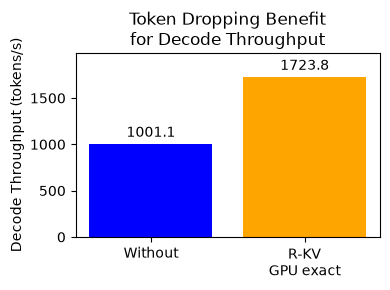

In [11]:
labels = ["Without", "R-KV\nGPU exact"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    gpu_exact_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Reading these numbers

All four notebooks were run back to back on one machine against the same vLLM
and LMCache servers, and each re-measures its own no-drop baseline. That gives
four independent measurements of an **identical** configuration — a direct read
on how much of any difference is real:

| | one-shot | gpu_exact | cpu_exact | buffered_cpu |
|---|---|---|---|---|
| baseline decode | 969 tok/s | 1008 tok/s | 1002 tok/s | 975 tok/s |
| baseline accuracy | 11/30 | 11/30 | 10/30 | 10/30 |
| decode after dropping | 1766 tok/s | 1774 tok/s | 1785 tok/s | 1774 tok/s |
| accuracy after dropping | 16/30 | 16/30 | 15/30 | 14/30 |

Three things follow.

1. **Decode throughput after dropping is the solid number.** It lands in
   1766–1785 tok/s — a 1.1% spread — although the four notebooks compress with
   completely different code. That is the claim this example makes: the speed-up
   comes from halving the KV cache, not from how the halving is computed.

2. **Don't quote a speed-up ratio.** The no-drop baseline swung 969–1008 tok/s
   here, and 894–1076 tok/s — **20%** — over an earlier sweep of the same four
   notebooks, so the ratio moves between 1.6x and 2.0x on noise alone. Compare
   the absolute post-drop throughput instead.

3. **Don't rank the variants by accuracy.** R-KV beat the same-run baseline in
   all four runs (+4 to +5 of 30), which is the meaningful result. But the 1/30
   spread *between* variants is the same size as the baseline's own spread, so
   it says nothing about the algorithms.

### Why identical inputs give different text

Decoding is greedy — `temperature = 0.0` for both prefill and decode — yet the
generated text still differs between runs. `temperature = 0` fixes the *rule*
(take the argmax); it does not make the argmax stable.

Prefill is submitted one stream at a time (`prefill_group_size = 1`) and it
**is** reproducible: 15.19 s and 15.21 s, to the same hundredth of a second, in
every notebook. Decode is not. `batch.decode` hands all 30 streams to vLLM at
once, so continuous batching gives the decode batch a different composition on
every run. GPU reductions are not batch-invariant, logits move by ~1e-6,
near-ties flip, and autoregression amplifies the divergence.

This is a property of the serving stack, not of token dropping — but it is the
reason a single accuracy number here should not be read as a ranking.

### The exact variants pick the same tokens — their caches still differ

Verified directly on real requests: `cpu_exact` and `gpu_exact` produce score
vectors that differ by ~1e-6, but the top-k they select was identical on every
request tested, and so were the kept token ids. Their compacted caches are
nevertheless not byte-identical:

| | differing elements | largest difference |
|---|---|---|
| V — a pure gather | **0** | 0 |
| K — goes through the RoPE re-rotation | 0.004% | one to two bfloat16 ULP |

Every difference is in K, and it is the *device*: `cpu_exact` re-rotates on the
CPU, `gpu_exact` on the GPU, and their sin/cos implementations and fused
multiply-adds round differently before the result is stored back as bfloat16.
Feeding one identical tensor to `rerotate_k_cache` on each device reproduces the
same signature exactly, so nothing else is involved.

One ULP in K is enough to move an attention logit, flip a near-tied greedy
argmax, and diverge from there. That is why two implementations which provably
select the same tokens still generate different text, and can land on a
different answer for one or two of the 30 questions.

#### Why the re-rotation runs in fp32

`utils.rerotate_k_cache` detaches one RoPE and attaches another: six multiplies
and two adds per element. Carrying that out in the cache's own bfloat16 rounds
at every step. Measured on keys with a standard deviation of 3:

| arithmetic | keys changed vs fp32 | rotate-away-and-back error | re-rotate 30 requests |
|---|---|---|---|
| bfloat16 | 50% | 2.5e-1 | 3.2 s |
| **fp32** (used here) | — | **6.3e-2** | 6.1 s |

fp32 costs 1.9x on the re-rotation step itself, because it moves twice the
bytes. End to end that is much less than it sounds: compressing the 30 requests
went from 41.4 to 41.6 s (one-shot), 37.3 to 37.5 s (`gpu_exact`) and 67.1 to
67.3 s (`cpu_exact`) — around +0.2 s, because `modify` spends most of its time
waiting on LMCache and the extra arithmetic fits in that slack. Only
`buffered_cpu` shows it, 27.9 to 29.9 s (+7%), because its compression is the
shortest so the re-rotation is the largest share of it. That buys a 4x better
round trip and takes an extra ULP of error off half the keys, so it is the
default. It does **not** remove the CPU/GPU split above: that is
the final rounding back to bfloat16, which is there whatever precision the
rotation is computed in.


## Close both contexts

In [12]:
# Only close the context when done.
ctx.close()
qctx.close()